# 📞 CallMeMaybe — Telecom Operator Performance Analysis

## Project Overview

This project analyses operational data from **CallMeMaybe**, a virtual telephony service, to identify operators showing potential signs of low efficiency while avoiding unfair conclusions caused by data-quality issues.

The analysis combines data cleaning, exploratory analysis, KPI development, sensitivity analysis, statistical testing, and business recommendations.

A key principle throughout the project is to separate calls that can be reliably attributed to an operator from calls with no identified `operator_id`.

### Portfolio Links

- **Tableau Public Dashboard:** [CallMeMaybe — Operator Efficiency](https://public.tableau.com/views/CallMeMaybe-EficinciadosOperadores/CallMeMaybe-Dashboard?:language=pt-BR&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)
- **Final presentation:** `CallMeMaybe_Apresentacao_Final.pdf`


## 1. Environment Setup

I import the libraries used throughout the analysis, configure table display options, and create helper functions to keep the notebook organised and reproducible.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from IPython.display import display, Markdown

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
def encontrar_arquivo(caminhos_possiveis):
    """Return the first existing file from a list of possible paths."""
    for caminho in caminhos_possiveis:
        caminho = Path(caminho)
        if caminho.exists():
            return caminho
    raise FileNotFoundError(
        'File not found. Check whether the CSV is in the same folder as the notebook or in /datasets.'
    )


def resumo_qualidade(df):
    """Return data types, missing values, missing-value percentage, and unique-value counts."""
    return pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing': df.isna().sum(),
        'missing_pct': (df.isna().mean() * 100).round(2),
        'unique_values': df.nunique(dropna=False)
    })


def interpretar_pvalor(p_value, alpha=0.05):
    """Interpret a p-value using the selected significance level."""
    if p_value < alpha:
        return 'Reject H0'
    return 'Do not reject H0'

## 2. Data Loading

I use a helper function to locate the input files automatically. This allows the notebook to run both locally and in the original course environment.


In [3]:
caminhos_telecom = [
    'telecom_dataset_new.csv',
    'telecom_dataset_us.csv',
    '/datasets/telecom_dataset_new.csv',
    '/datasets/telecom_dataset_us.csv'
]

caminhos_clients = [
    'telecom_clients.csv',
    'telecom_clients_us.csv',
    '/datasets/telecom_clients.csv',
    '/datasets/telecom_clients_us.csv'
]

telecom_path = encontrar_arquivo(caminhos_telecom)
clients_path = encontrar_arquivo(caminhos_clients)

telecom_raw = pd.read_csv(telecom_path)
clients_raw = pd.read_csv(clients_path)

print('Files loaded successfully!')
print('Calls dataset:', telecom_path)
print('Clients dataset:', clients_path)

Files loaded successfully!
Calls dataset: telecom_dataset_new.csv
Clients dataset: telecom_clients.csv


In [4]:
print('Calls dataset shape:', telecom_raw.shape)
print('Clients dataset shape:', clients_raw.shape)

display(telecom_raw.head())
display(clients_raw.head())

Calls dataset shape: (53902, 9)
Clients dataset shape: (732, 3)


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,"880,022.0000",True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,"880,020.0000",True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,"880,020.0000",False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,"880,022.0000",True,3,0,25


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


## 3. Initial Data Quality Review

Before classifying operators, I review data types, missing values, duplicates, and the frequency of key categorical variables.


In [5]:
print('Initial data quality — calls')
display(resumo_qualidade(telecom_raw))
print('Exact duplicates — calls:', telecom_raw.duplicated().sum())

print('\nInitial data quality — clients')
display(resumo_qualidade(clients_raw))
print('Exact duplicates — clients:', clients_raw.duplicated().sum())

Initial data quality — calls


,dtype,missing,missing_pct,unique_values
user_id,int64,0,0.0000,307
date,object,0,0.0000,119
direction,object,0,0.0000,2
internal,object,117,0.2200,3
operator_id,float64,8172,15.1600,1093
is_missed_call,bool,0,0.0000,2
calls_count,int64,0,0.0000,502
call_duration,int64,0,0.0000,5373
total_call_duration,int64,0,0.0000,6040


Exact duplicates — calls: 4900

Initial data quality — clients


,dtype,missing,missing_pct,unique_values
user_id,int64,0,0.0000,732
tariff_plan,object,0,0.0000,3
date_start,object,0,0.0000,73


Exact duplicates — clients: 0


In [6]:
for coluna in ['direction', 'internal', 'is_missed_call']:
    print(f'\nFrequency of {coluna}:')
    display(telecom_raw[coluna].value_counts(dropna=False).to_frame('count'))

print('\nTariff-plan frequency:')
display(clients_raw['tariff_plan'].value_counts(dropna=False).to_frame('clients'))


Frequency of direction:


,count
direction,
out,31917
in,21985



Frequency of internal:


,count
internal,
False,47621
True,6164
NaN,117



Frequency of is_missed_call:


,count
is_missed_call,
False,30334
True,23568



Tariff-plan frequency:


,clients
tariff_plan,
C,395
B,261
A,76


### Initial Observations

The calls dataset contains exact duplicates and missing values in `operator_id`. Because `operator_id` identifies the operator responsible for a call, I do not fill these values artificially.

Calls without an identified operator are retained for the overall analysis, but they are not used to assign responsibility to individual operators.


## 4. Data Cleaning and Preparation

I remove exact duplicates, standardise date fields, create an integer operator identifier, and calculate derived variables for waiting time and missed calls.


In [7]:
def preparar_dados(telecom_df, clients_df):
    """Clean the data and create derived variables required for the analysis."""
    telecom = telecom_df.drop_duplicates().copy()
    clients = clients_df.drop_duplicates().copy()

    # The original timestamp includes a timezone. For daily analysis, preserve the calendar date recorded in the source.
    telecom['date'] = pd.to_datetime(telecom['date'].astype(str).str[:10])
    clients['date_start'] = pd.to_datetime(clients['date_start'])

    telecom['internal'] = telecom['internal'].astype('boolean')
    telecom['operator_id_int'] = telecom['operator_id'].astype('Int64')

    telecom['wait_duration'] = telecom['total_call_duration'] - telecom['call_duration']
    telecom['avg_call_duration_per_call'] = np.where(
        telecom['calls_count'] > 0,
        telecom['call_duration'] / telecom['calls_count'],
        np.nan
    )
    telecom['avg_wait_per_call'] = np.where(
        telecom['calls_count'] > 0,
        telecom['wait_duration'] / telecom['calls_count'],
        np.nan
    )
    telecom['missed_calls_count'] = np.where(
        telecom['is_missed_call'],
        telecom['calls_count'],
        0
    )

    return telecom, clients

telecom, clients = preparar_dados(telecom_raw, clients_raw)

print('Original rows:', len(telecom_raw))
print('Rows after removing duplicates:', len(telecom))
print('Duplicates removed:', len(telecom_raw) - len(telecom))

Original rows: 53902
Rows after removing duplicates: 49002
Duplicates removed: 4900


In [8]:
verificacoes = pd.Series({
    'calls_count <= 0': (telecom['calls_count'] <= 0).sum(),
    'call_duration < 0': (telecom['call_duration'] < 0).sum(),
    'total_call_duration < 0': (telecom['total_call_duration'] < 0).sum(),
    'total_call_duration < call_duration': (telecom['total_call_duration'] < telecom['call_duration']).sum(),
    'wait_duration < 0': (telecom['wait_duration'] < 0).sum()
})

display(verificacoes.to_frame('count'))

,count
calls_count <= 0,0
call_duration < 0,0
total_call_duration < 0,0
total_call_duration < call_duration,0
wait_duration < 0,0


In [9]:
print('Call period:')
print(telecom['date'].min().date(), 'to', telecom['date'].max().date())
print('\nNumber of days in period:', telecom['date'].nunique())
print('Active clients:', telecom['user_id'].nunique())
print('Identified operators:', telecom['operator_id_int'].nunique())
print('Registered clients:', clients['user_id'].nunique())
print('Total call volume:', int(telecom['calls_count'].sum()))

Call period:
2019-08-02 to 2019-11-28

Number of days in period: 119
Active clients: 307
Identified operators: 1092
Registered clients: 732
Total call volume: 806709


In [10]:
variaveis_numericas = [
    'calls_count',
    'call_duration',
    'total_call_duration',
    'wait_duration',
    'avg_wait_per_call'
]

display(
    telecom[variaveis_numericas]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .T
    .round(2)
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
calls_count,"49,002.0000",16.4600,63.6000,1.0000,1.0000,4.0000,12.0000,35.0000,62.0000,165.0000,"4,817.0000"
call_duration,"49,002.0000",866.2800,"3,775.5000",0.0000,0.0000,37.0000,570.0000,"2,092.0000","3,725.9500","10,314.9100","144,395.0000"
total_call_duration,"49,002.0000","1,156.5600","4,451.4700",0.0000,46.0000,208.0000,901.0000,"2,610.8000","4,531.0000","12,956.0000","166,155.0000"
wait_duration,"49,002.0000",290.2800,"1,132.1600",0.0000,17.0000,55.0000,200.0000,613.0000,"1,163.0000","3,157.9100","46,474.0000"
avg_wait_per_call,"49,002.0000",16.8300,13.8800,0.0000,8.0000,14.5000,22.2500,32.2100,40.0000,60.0000,465.0000


### Data Cleaning Conclusion

After removing duplicates, no relevant numerical inconsistencies remain: there are no records with non-positive call counts or negative duration values.

Because call volumes and durations are highly skewed, I use medians, percentiles, distributions, and other robust measures alongside averages to avoid conclusions being driven by extreme values.


## 5. Client Data Integration

I merge the call data with the client dataset to include tariff-plan information for complementary analysis.


In [11]:
base = telecom.merge(clients, on='user_id', how='left')

print('Rows after merge:', len(base))
print('Records without tariff plan:', base['tariff_plan'].isna().sum())
display(base.head())

Rows after merge: 49002
Records without tariff plan: 0


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,operator_id_int,wait_duration,avg_call_duration_per_call,avg_wait_per_call,missed_calls_count,tariff_plan,date_start
0,166377,2019-08-04,in,False,NaN,True,2,0,4,<NA>,4,0.0000,2.0000,2,B,2019-08-01
1,166377,2019-08-05,out,True,"880,022.0000",True,3,0,5,880022,5,0.0000,1.6667,3,B,2019-08-01
2,166377,2019-08-05,out,True,"880,020.0000",True,1,0,1,880020,1,0.0000,1.0000,1,B,2019-08-01
3,166377,2019-08-05,out,True,"880,020.0000",False,1,10,18,880020,8,10.0000,8.0000,0,B,2019-08-01
4,166377,2019-08-05,out,False,"880,022.0000",True,3,0,25,880022,25,0.0000,8.3333,3,B,2019-08-01


## 6. Overall Exploratory Analysis

I analyse call volumes, missed-call rates, and waiting times by call direction to understand the broader operational context before evaluating individual operators.


In [12]:
resumo_direcao = (
    base.groupby('direction')
    .agg(
        records=('calls_count', 'size'),
        calls=('calls_count', 'sum'),
        missed_calls=('missed_calls_count', 'sum'),
        total_wait=('wait_duration', 'sum')
    )
    .assign(
        missed_rate=lambda df: df['missed_calls'] / df['calls'],
        avg_wait_per_call=lambda df: df['total_wait'] / df['calls']
    )
    .reset_index()
)

display(resumo_direcao)

,direction,records,calls,missed_calls,total_wait,missed_rate,avg_wait_per_call
0,in,20003,197845,104323,2496917,0.5273,12.6206
1,out,28999,608864,271595,11727193,0.4461,19.2608


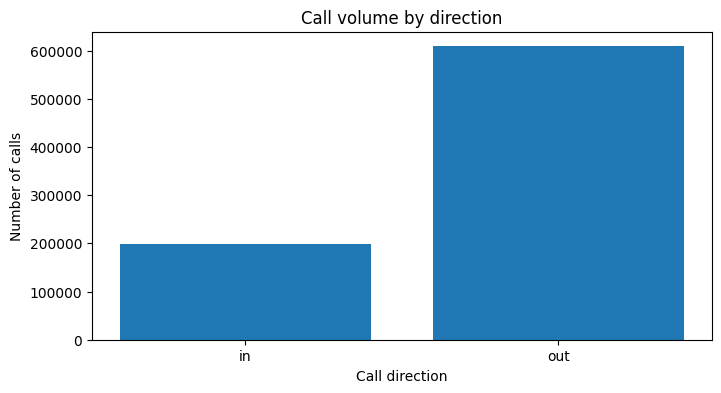

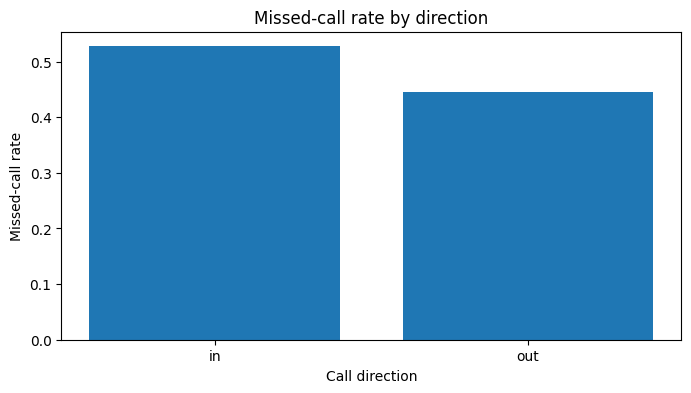

In [13]:
plt.figure(figsize=(8, 4))
plt.bar(resumo_direcao['direction'], resumo_direcao['calls'])
plt.title('Call volume by direction')
plt.xlabel('Call direction')
plt.ylabel('Number of calls')
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(resumo_direcao['direction'], resumo_direcao['missed_rate'])
plt.title('Missed-call rate by direction')
plt.xlabel('Call direction')
plt.ylabel('Missed-call rate')
plt.show()

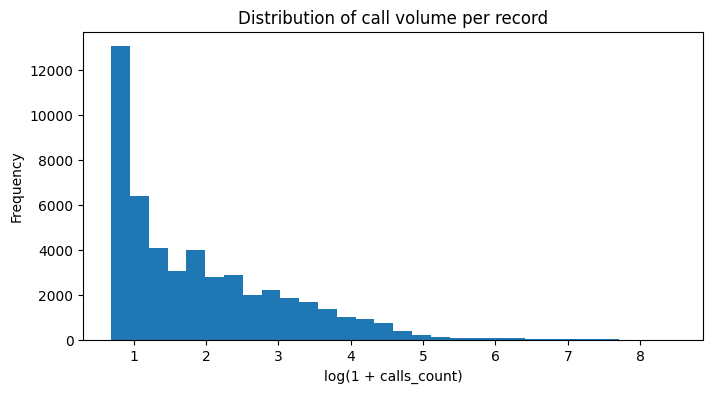

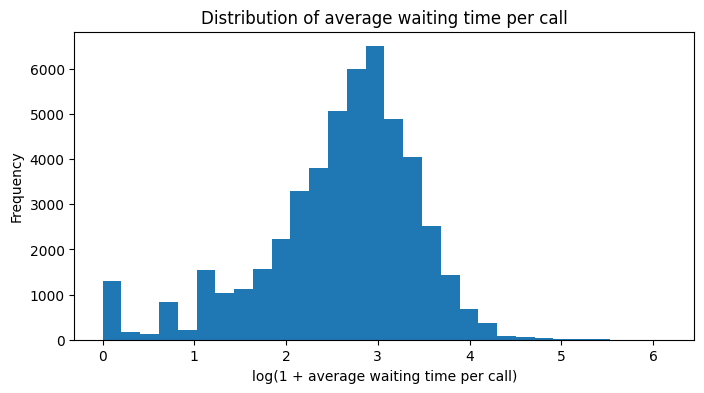

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(base['calls_count']), bins=30)
plt.title('Distribution of call volume per record')
plt.xlabel('log(1 + calls_count)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(base['avg_wait_per_call']), bins=30)
plt.title('Distribution of average waiting time per call')
plt.xlabel('log(1 + average waiting time per call)')
plt.ylabel('Frequency')
plt.show()

## 7. Calls Without an Identified Operator

This is a critical part of the analysis. If a call does not contain an `operator_id`, it cannot be safely attributed to a specific operator.

Separating these calls helps prevent operator-performance conclusions from being distorted by routing, service, or data-recording issues.


In [15]:
analise_operador_ausente = (
    base.assign(operator_missing=base['operator_id_int'].isna())
    .groupby(['direction', 'operator_missing', 'is_missed_call'], dropna=False)
    .agg(records=('calls_count', 'size'), calls=('calls_count', 'sum'))
    .reset_index()
)

display(analise_operador_ausente)

,direction,operator_missing,is_missed_call,records,calls
0,in,False,False,12048,92876
1,in,False,True,685,926
2,in,True,False,68,646
3,in,True,True,7202,103397
4,out,False,False,15388,336950
5,out,False,True,13425,271393
6,out,True,False,45,319
7,out,True,True,141,202


In [16]:
recebidas = base[base['direction'] == 'in'].copy()

volume_recebidas = recebidas['calls_count'].sum()
volume_recebidas_sem_operador = recebidas.loc[recebidas['operator_id_int'].isna(), 'calls_count'].sum()
perdidas_recebidas_sem_operador = recebidas.loc[
    recebidas['operator_id_int'].isna() & recebidas['is_missed_call'],
    'calls_count'
].sum()
volume_recebidas_com_operador = recebidas.loc[recebidas['operator_id_int'].notna(), 'calls_count'].sum()
perdidas_recebidas_com_operador = recebidas.loc[
    recebidas['operator_id_int'].notna() & recebidas['is_missed_call'],
    'calls_count'
].sum()

resumo_operador_ausente = pd.Series({
    'total_inbound_calls': volume_recebidas,
    'inbound_calls_without_operator': volume_recebidas_sem_operador,
    'share_inbound_without_operator': volume_recebidas_sem_operador / volume_recebidas,
    'missed_rate_inbound_without_operator': perdidas_recebidas_sem_operador / volume_recebidas_sem_operador,
    'missed_rate_inbound_with_operator': perdidas_recebidas_com_operador / volume_recebidas_com_operador
})

display(resumo_operador_ausente.to_frame('value'))

,value
total_inbound_calls,"197,845.0000"
inbound_calls_without_operator,"104,043.0000"
share_inbound_without_operator,0.5259
missed_rate_inbound_without_operator,0.9938
missed_rate_inbound_with_operator,0.0099


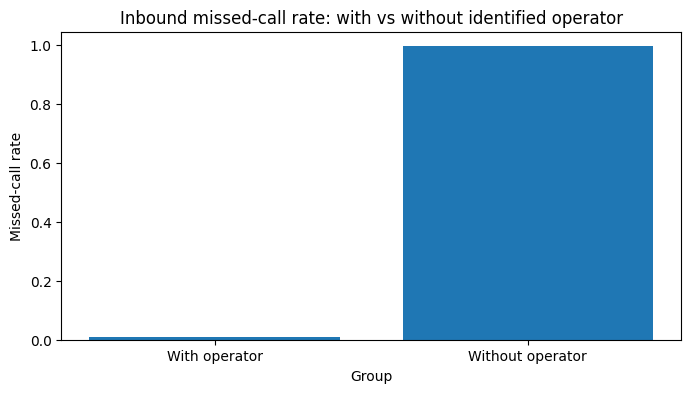

In [17]:
plot_operador_ausente = pd.DataFrame({
    'group': ['With operator', 'Without operator'],
    'taxa_perda': [
        perdidas_recebidas_com_operador / volume_recebidas_com_operador,
        perdidas_recebidas_sem_operador / volume_recebidas_sem_operador
    ]
})

plt.figure(figsize=(8, 4))
plt.bar(plot_operador_ausente['group'], plot_operador_ausente['taxa_perda'])
plt.title('Inbound missed-call rate: with vs without identified operator')
plt.xlabel('Group')
plt.ylabel('Missed-call rate')
plt.show()

In [18]:
display(Markdown(f"""
### Business Interpretation

During the analysed period, **{volume_recebidas_sem_operador / volume_recebidas:.1%}** of inbound calls do not have an identified operator. Within this group, the missed-call rate is **{perdidas_recebidas_sem_operador / volume_recebidas_sem_operador:.1%}**.

By contrast, the missed-call rate among inbound calls with an identified operator is only **{perdidas_recebidas_com_operador / volume_recebidas_com_operador:.1%}**.

This indicates that a large share of missed inbound calls should not be attributed directly to individual operators. These calls should be monitored separately as a possible routing, service, or data-recording issue.
"""))


### Business Interpretation

During the analysed period, **52.6%** of inbound calls do not have an identified operator. Within this group, the missed-call rate is **99.4%**.

By contrast, the missed-call rate among inbound calls with an identified operator is only **1.0%**.

This indicates that a large share of missed inbound calls should not be attributed directly to individual operators. These calls should be monitored separately as a possible routing, service, or data-recording issue.


## 8. Operator-Level KPIs

I build the main analytical table with one row per identified operator and calculate KPIs for inbound calls, outbound calls, waiting time, active days, and operational profile.


In [19]:
def calcular_kpis_operador(df):
    """Calculate inbound, outbound, waiting-time, and profile KPIs by operator."""
    operadores = df[df['operator_id_int'].notna()].copy()

    direcoes = operadores.pivot_table(
        index='operator_id_int',
        columns='direction',
        values='calls_count',
        aggfunc='sum',
        fill_value=0
    )

    for direcao in ['in', 'out']:
        if direcao not in direcoes.columns:
            direcoes[direcao] = 0

    kpis = pd.DataFrame(index=direcoes.index)
    kpis['operator_id'] = kpis.index.astype(int)
    kpis['inbound_calls'] = direcoes['in']
    kpis['outbound_calls'] = direcoes['out']
    kpis['total_calls'] = kpis['inbound_calls'] + kpis['outbound_calls']
    kpis['active_days'] = operadores.groupby('operator_id_int')['date'].nunique()
    kpis['client_count'] = operadores.groupby('operator_id_int')['user_id'].nunique()
    kpis['first_date'] = operadores.groupby('operator_id_int')['date'].min()
    kpis['last_date'] = operadores.groupby('operator_id_int')['date'].max()

    condicoes = [
        (kpis['inbound_calls'] > 0) & (kpis['outbound_calls'] > 0),
        (kpis['inbound_calls'] > 0) & (kpis['outbound_calls'] == 0),
        (kpis['inbound_calls'] == 0) & (kpis['outbound_calls'] > 0)
    ]
    kpis['profile'] = np.select(condicoes, ['mixed', 'inbound', 'outbound'], default='unknown')

    entrada = operadores[operadores['direction'] == 'in']
    saida = operadores[operadores['direction'] == 'out']

    kpis['missed_inbound_calls'] = (
        entrada.groupby('operator_id_int')['missed_calls_count'].sum().reindex(kpis.index, fill_value=0)
    )
    kpis['inbound_wait_total'] = (
        entrada.groupby('operator_id_int')['wait_duration'].sum().reindex(kpis.index, fill_value=0)
    )
    kpis['outbound_active_days'] = (
        saida.groupby('operator_id_int')['date'].nunique().reindex(kpis.index, fill_value=0)
    )

    kpis['missed_rate'] = kpis['missed_inbound_calls'] / kpis['inbound_calls'].replace(0, np.nan)
    kpis['avg_wait_per_in_call'] = kpis['inbound_wait_total'] / kpis['inbound_calls'].replace(0, np.nan)
    kpis['inbound_calls_per_active_day'] = kpis['inbound_calls'] / kpis['active_days'].replace(0, np.nan)
    kpis['outbound_calls_per_active_day'] = kpis['outbound_calls'] / kpis['outbound_active_days'].replace(0, np.nan)

    return kpis.reset_index(drop=True)

operator_kpis = calcular_kpis_operador(base)
display(operator_kpis.head())

,operator_id,inbound_calls,outbound_calls,total_calls,active_days,client_count,first_date,last_date,profile,missed_inbound_calls,inbound_wait_total,outbound_active_days,missed_rate,avg_wait_per_in_call,inbound_calls_per_active_day,outbound_calls_per_active_day
0,879896,58,872,930,50,1,2019-08-02,2019-11-25,mixed,0,574,49,0.0000,9.8966,1.1600,17.7959
1,879898,104,7209,7313,84,1,2019-08-02,2019-11-28,mixed,0,1680,82,0.0000,16.1538,1.2381,87.9146
2,880020,7,38,45,14,1,2019-08-05,2019-10-03,mixed,0,54,7,0.0000,7.7143,0.5000,5.4286
3,880022,8,189,197,42,1,2019-08-05,2019-11-28,mixed,0,112,36,0.0000,14.0000,0.1905,5.2500
4,880026,24,2208,2232,77,1,2019-08-07,2019-11-28,mixed,0,143,77,0.0000,5.9583,0.3117,28.6753


In [20]:
print('Operators available for evaluation:', operator_kpis['operator_id'].nunique())

print('\nOperator profile distribution:')
display(operator_kpis['profile'].value_counts().to_frame('operators'))

print('\nSummary of key KPIs:')
display(
    operator_kpis[
        ['inbound_calls', 'outbound_calls', 'missed_rate', 'avg_wait_per_in_call',
         'outbound_calls_per_active_day', 'active_days']
    ]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .T
    .round(4)
)

Operators available for evaluation: 1092

Operator profile distribution:


,operators
profile,
mixed,544
outbound,338
inbound,210



Summary of key KPIs:


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
inbound_calls,"1,092.0000",85.8993,301.6696,0.0000,0.0000,5.0000,34.2500,189.9000,421.1500,"1,294.0800","4,766.0000"
outbound_calls,"1,092.0000",557.0907,"2,819.4922",0.0000,2.0000,33.0000,355.2500,"1,366.1000","2,239.9500","4,689.4600","58,977.0000"
missed_rate,754.0000,0.0176,0.0653,0.0000,0.0000,0.0000,0.0067,0.0370,0.0913,0.2994,1.0000
avg_wait_per_in_call,754.0000,17.4916,12.1720,0.6837,9.3988,14.4305,21.8389,33.8701,41.5792,55.3821,115.5000
outbound_calls_per_active_day,882.0000,29.3910,67.0480,1.0000,2.6667,6.5861,29.0000,90.1167,126.5973,202.9925,816.7917
active_days,"1,092.0000",17.9918,18.7715,1.0000,3.7500,12.0000,26.2500,46.0000,59.0000,78.0900,97.0000


## 9. Inefficiency Criteria

Because the company does not provide official performance targets, I use relative thresholds derived from the dataset. These thresholds are treated as preliminary and are later tested through sensitivity analysis.

### Baseline criteria

- **High missed-call rate:** inbound missed-call rate at or above the 90th percentile.
- **High waiting time:** average waiting time per inbound call at or above the 75th percentile.
- **Low outbound activity:** outbound calls per active day at or below the 25th percentile.
- **Inbound eligibility:** at least 20 inbound calls and 3 active days.
- **Outbound eligibility:** at least 3 active days with outbound calls.

These rules are designed as a prioritisation framework, not as an automatic judgement of operator performance.


In [21]:
def obter_limites(kpis, min_inbound_calls=20, min_active_days=3,
                  missed_percentile=0.90, wait_percentile=0.75,
                  outbound_percentile=0.25):
    """Calculate percentile-based thresholds within eligible operator groups."""
    entrada_elegivel = kpis[
        (kpis['inbound_calls'] >= min_inbound_calls) &
        (kpis['active_days'] >= min_active_days)
    ]
    saida_elegivel = kpis[
        (kpis['outbound_active_days'] >= min_active_days) &
        (kpis['outbound_calls'] > 0)
    ]

    return {
        'min_inbound_calls': min_inbound_calls,
        'min_active_days': min_active_days,
        'missed_rate_limit': entrada_elegivel['missed_rate'].quantile(missed_percentile),
        'avg_wait_limit': entrada_elegivel['avg_wait_per_in_call'].quantile(wait_percentile),
        'outbound_activity_limit': saida_elegivel['outbound_calls_per_active_day'].quantile(outbound_percentile),
        'eligible_inbound_count': len(entrada_elegivel),
        'eligible_outbound_count': len(saida_elegivel)
    }

limites_base = obter_limites(operator_kpis)
display(pd.Series(limites_base).to_frame('value'))

,value
min_inbound_calls,20.0000
min_active_days,3.0000
missed_rate_limit,0.0369
avg_wait_limit,20.7742
outbound_activity_limit,3.5402
eligible_inbound_count,353.0000
eligible_outbound_count,694.0000


In [22]:
def classificar_operadores(kpis, limites):
    """Classify operators based on negative signals applicable to their profile."""
    resultado = kpis.copy()

    resultado['eligible_inbound'] = (
        (resultado['inbound_calls'] >= limites['min_inbound_calls']) &
        (resultado['active_days'] >= limites['min_active_days'])
    )
    resultado['eligible_outbound'] = (
        (resultado['outbound_active_days'] >= limites['min_active_days']) &
        (resultado['outbound_calls'] > 0)
    )

    resultado['flag_high_missed_rate'] = (
        resultado['eligible_inbound'] &
        (resultado['missed_rate'] >= limites['missed_rate_limit'])
    )
    resultado['flag_high_wait'] = (
        resultado['eligible_inbound'] &
        (resultado['avg_wait_per_in_call'] >= limites['avg_wait_limit'])
    )
    resultado['flag_low_outbound_activity'] = (
        resultado['eligible_outbound'] &
        (resultado['outbound_calls_per_active_day'] <= limites['outbound_activity_limit'])
    )

    resultado['applicable_indicators'] = 0
    resultado.loc[resultado['eligible_inbound'], 'applicable_indicators'] += 2
    resultado.loc[resultado['eligible_outbound'], 'applicable_indicators'] += 1

    flags = ['flag_high_missed_rate', 'flag_high_wait', 'flag_low_outbound_activity']
    resultado['negative_signals'] = resultado[flags].sum(axis=1)
    resultado['inefficiency_score'] = resultado['negative_signals'] / resultado['applicable_indicators'].replace(0, np.nan)

    resultado['priority'] = np.select(
        [resultado['inefficiency_score'] >= 2 / 3, resultado['negative_signals'] >= 1],
        ['high priority', 'attention'],
        default='no signal'
    )

    return resultado

operator_classification = classificar_operadores(operator_kpis, limites_base)
display(operator_classification.head())

,operator_id,inbound_calls,outbound_calls,total_calls,active_days,client_count,first_date,last_date,profile,missed_inbound_calls,inbound_wait_total,outbound_active_days,missed_rate,avg_wait_per_in_call,inbound_calls_per_active_day,outbound_calls_per_active_day,eligible_inbound,eligible_outbound,flag_high_missed_rate,flag_high_wait,flag_low_outbound_activity,applicable_indicators,negative_signals,inefficiency_score,priority
0,879896,58,872,930,50,1,2019-08-02,2019-11-25,mixed,0,574,49,0.0000,9.8966,1.1600,17.7959,True,True,False,False,False,3,0,0.0000,no signal
1,879898,104,7209,7313,84,1,2019-08-02,2019-11-28,mixed,0,1680,82,0.0000,16.1538,1.2381,87.9146,True,True,False,False,False,3,0,0.0000,no signal
2,880020,7,38,45,14,1,2019-08-05,2019-10-03,mixed,0,54,7,0.0000,7.7143,0.5000,5.4286,False,True,False,False,False,1,0,0.0000,no signal
3,880022,8,189,197,42,1,2019-08-05,2019-11-28,mixed,0,112,36,0.0000,14.0000,0.1905,5.2500,False,True,False,False,False,1,0,0.0000,no signal
4,880026,24,2208,2232,77,1,2019-08-07,2019-11-28,mixed,0,143,77,0.0000,5.9583,0.3117,28.6753,True,True,False,False,False,3,0,0.0000,no signal


In [23]:
resumo_classificacao = (
    operator_classification['priority']
    .value_counts()
    .rename_axis('priority')
    .reset_index(name='operators')
)

display(resumo_classificacao)

print('Negative signals identified:')
display(
    operator_classification[
        ['flag_high_missed_rate', 'flag_high_wait', 'flag_low_outbound_activity']
    ].sum().to_frame('operators')
)

,priority,operators
0,no signal,831
1,high priority,152
2,attention,109


Negative signals identified:


,operators
flag_high_missed_rate,36
flag_high_wait,89
flag_low_outbound_activity,174


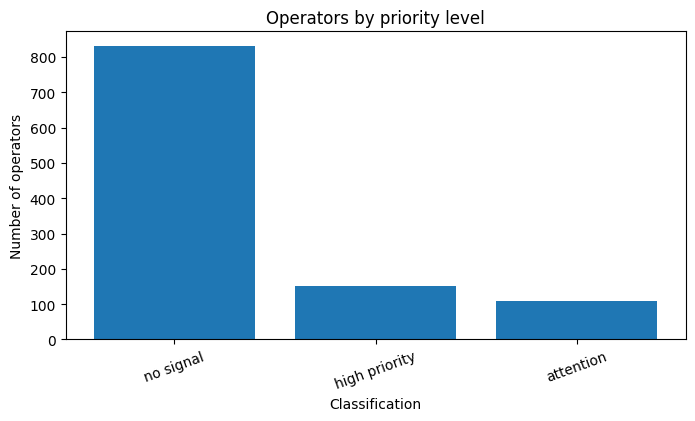

In [24]:
plt.figure(figsize=(8, 4))
plt.bar(resumo_classificacao['priority'], resumo_classificacao['operators'])
plt.title('Operators by priority level')
plt.xlabel('Classification')
plt.ylabel('Number of operators')
plt.xticks(rotation=20)
plt.show()

In [25]:
colunas_ranking = [
    'operator_id', 'profile', 'active_days', 'inbound_calls', 'missed_rate',
    'avg_wait_per_in_call', 'outbound_calls', 'outbound_calls_per_active_day',
    'negative_signals', 'applicable_indicators', 'inefficiency_score', 'priority'
]

operadores_prioritarios = (
    operator_classification
    .query("priority == 'high priority'")
    .sort_values(
        ['inefficiency_score', 'negative_signals', 'missed_rate', 'avg_wait_per_in_call'],
        ascending=[False, False, False, False]
    )
)

display(operadores_prioritarios[colunas_ranking].head(20))

,operator_id,profile,active_days,inbound_calls,missed_rate,avg_wait_per_in_call,outbound_calls,outbound_calls_per_active_day,negative_signals,applicable_indicators,inefficiency_score,priority
675,937368,mixed,12,22,0.1818,24.1364,10,2.5000,3,3,1.0000,high priority
246,905300,inbound,15,25,0.2400,22.0800,0,NaN,2,2,1.0000,high priority
349,911102,inbound,18,27,0.1111,30.4444,0,NaN,2,2,1.0000,high priority
354,911142,inbound,13,20,0.1000,46.1500,0,NaN,2,2,1.0000,high priority
163,899268,inbound,24,31,0.0645,20.7742,0,NaN,2,2,1.0000,high priority
361,912684,inbound,14,27,0.0370,35.4815,0,NaN,2,2,1.0000,high priority
272,906392,mixed,22,18,0.3889,13.8333,53,2.6500,1,1,1.0000,high priority
148,897872,mixed,19,3,0.3333,21.6667,49,2.5789,1,1,1.0000,high priority
999,957922,mixed,5,3,0.3333,8.6667,16,3.2000,1,1,1.0000,high priority
113,894232,mixed,10,4,0.2500,10.7500,16,2.0000,1,1,1.0000,high priority


In [26]:
display(Markdown(f"""
### Preliminary Classification Result

Using the baseline criteria, **{(operator_classification['priority'] == 'high priority').sum()} operators were classified as high priority** and **{(operator_classification['priority'] == 'attention').sum()} as requiring attention**.

This classification is designed to help supervisors prioritise investigation. It should not be used as an automatic punitive measure, because operators may work under different operational contexts.
"""))


### Preliminary Classification Result

Using the baseline criteria, **152 operators were classified as high priority** and **109 as requiring attention**.

This classification is designed to help supervisors prioritise investigation. It should not be used as an automatic punitive measure, because operators may work under different operational contexts.


## 10. Sensitivity Analysis

I test different combinations of minimum activity levels and percentile thresholds to assess how stable the classification is.

Operators that remain flagged as high priority across many scenarios represent more robust candidates for further investigation.


In [27]:
def analise_sensibilidade(kpis):
    """Run multiple classification scenarios for sensitivity analysis."""
    cenarios = []
    frequencia = pd.Series(0, index=kpis.index, dtype=float)
    total_cenarios = 0

    for min_calls in [10, 20, 30, 50]:
        for min_days in [2, 3, 5]:
            for missed_pct in [0.85, 0.90, 0.95]:
                for wait_pct in [0.70, 0.75, 0.80]:
                    for outbound_pct in [0.20, 0.25, 0.30]:
                        limites = obter_limites(
                            kpis,
                            min_inbound_calls=min_calls,
                            min_active_days=min_days,
                            missed_percentile=missed_pct,
                            wait_percentile=wait_pct,
                            outbound_percentile=outbound_pct
                        )
                        classificado = classificar_operadores(kpis, limites)
                        alta = classificado['priority'] == 'high priority'
                        total_cenarios += 1
                        frequencia += alta.astype(int)

                        cenarios.append({
                            'min_calls': min_calls,
                            'min_days': min_days,
                            'missed_percentile': missed_pct,
                            'wait_percentile': wait_pct,
                            'outbound_percentile': outbound_pct,
                            'flagged_count': int(alta.sum())
                        })

    return pd.DataFrame(cenarios), frequencia / total_cenarios

sensitivity_results, sensitivity_frequency = analise_sensibilidade(operator_kpis)
operator_classification['sensitivity_frequency'] = sensitivity_frequency.values

print('Number of scenarios tested:', len(sensitivity_results))
display(sensitivity_results['flagged_count'].describe().to_frame('flagged_operators'))

Number of scenarios tested: 324


,flagged_operators
count,324.0000
mean,152.6574
std,28.2168
min,89.0000
25%,131.0000
50%,150.0000
75%,173.0000
max,223.0000


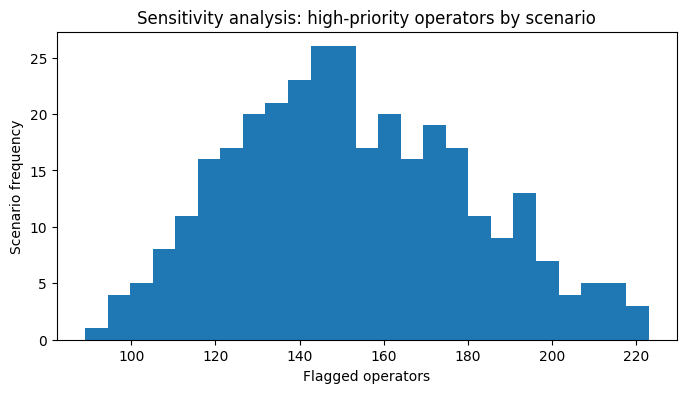

In [28]:
plt.figure(figsize=(8, 4))
plt.hist(sensitivity_results['flagged_count'], bins=25)
plt.title('Sensitivity analysis: high-priority operators by scenario')
plt.xlabel('Flagged operators')
plt.ylabel('Scenario frequency')
plt.show()

In [29]:
operadores_robustos = (
    operator_classification
    .sort_values('sensitivity_frequency', ascending=False)
    [colunas_ranking + ['sensitivity_frequency']]
)

display(operadores_robustos.head(20))

,operator_id,profile,active_days,inbound_calls,missed_rate,avg_wait_per_in_call,outbound_calls,outbound_calls_per_active_day,negative_signals,applicable_indicators,inefficiency_score,priority,sensitivity_frequency
1009,958454,mixed,10,2,0.0000,15.0000,24,2.4000,1,1,1.0000,high priority,1.0000
1014,958470,mixed,8,3,0.0000,50.6667,13,1.8571,1,1,1.0000,high priority,1.0000
994,956298,outbound,8,0,NaN,NaN,14,1.7500,1,1,1.0000,high priority,1.0000
54,890232,outbound,15,0,NaN,NaN,33,2.2000,1,1,1.0000,high priority,1.0000
40,888406,mixed,12,9,0.1111,28.3333,6,1.0000,1,1,1.0000,high priority,1.0000
44,888536,mixed,23,2,0.0000,21.5000,52,2.2609,1,1,1.0000,high priority,1.0000
45,888538,mixed,5,1,0.0000,24.0000,5,1.0000,1,1,1.0000,high priority,1.0000
46,888540,mixed,10,3,0.0000,19.6667,14,1.7500,1,1,1.0000,high priority,1.0000
985,955090,outbound,10,0,NaN,NaN,26,2.6000,1,1,1.0000,high priority,1.0000
989,955820,outbound,5,0,NaN,NaN,9,1.8000,1,1,1.0000,high priority,1.0000


In [30]:
display(Markdown(f"""
### Sensitivity Analysis Interpretation

A total of **{len(sensitivity_results)} scenarios** were tested. The number of high-priority operators ranged from **{sensitivity_results['flagged_count'].min()}** to **{sensitivity_results['flagged_count'].max()}**.

Operators that remain flagged across many scenarios should receive greater attention because the alert is less dependent on a single threshold choice.
"""))


### Sensitivity Analysis Interpretation

A total of **324 scenarios** were tested. The number of high-priority operators ranged from **89** to **223**.

Operators that remain flagged across many scenarios should receive greater attention because the alert is less dependent on a single threshold choice.


## 11. Statistical Tests

I test the hypotheses defined for the analysis using a significance level of **α = 0.05**.


### Hypothesis 1 — Waiting Time and Missed-Call Rate

**H0:** Operators with higher average waiting times do not have a higher inbound missed-call rate.

**H1:** Operators with higher average waiting times have a higher inbound missed-call rate.

I use **Spearman correlation** because the variables are skewed and may contain outliers.


In [31]:
alpha = 0.05

base_teste_espera = operator_classification[
    operator_classification['eligible_inbound']
].dropna(subset=['avg_wait_per_in_call', 'missed_rate'])

spearman_wait = stats.spearmanr(
    base_teste_espera['avg_wait_per_in_call'],
    base_teste_espera['missed_rate']
)

print('Spearman correlation:', round(spearman_wait.statistic, 4))
print('p-value:', spearman_wait.pvalue)
print('Decision:', interpretar_pvalor(spearman_wait.pvalue, alpha))

Spearman correlation: 0.1215
p-value: 0.022472819501656204
Decision: Reject H0


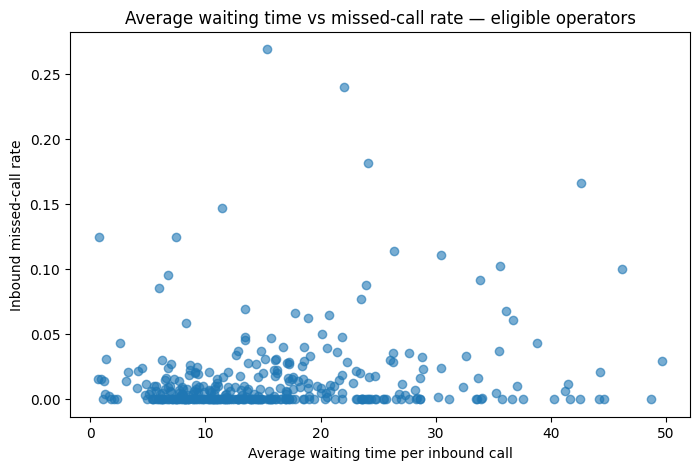

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(base_teste_espera['avg_wait_per_in_call'], base_teste_espera['missed_rate'], alpha=0.6)
plt.title('Average waiting time vs missed-call rate — eligible operators')
plt.xlabel('Average waiting time per inbound call')
plt.ylabel('Inbound missed-call rate')
plt.show()

In [33]:
display(Markdown(f"""
**Hypothesis 1 conclusion:** {interpretar_pvalor(spearman_wait.pvalue, alpha)}. The correlation was **{spearman_wait.statistic:.4f}** and the p-value was **{spearman_wait.pvalue:.4f}**.

The association is statistically significant but weak. This suggests that waiting time may contribute to missed calls, but it does not explain operator inefficiency on its own.
"""))


**Hypothesis 1 conclusion:** Reject H0. The correlation was **0.1215** and the p-value was **0.0225**.

The association is statistically significant but weak. This suggests that waiting time may contribute to missed calls, but it does not explain operator inefficiency on its own.


### Hypothesis 2 — Internal vs External Inbound Calls

**H0:** Among inbound calls attributed to operators, the proportion of missed calls is the same for internal and external calls.

**H1:** Among inbound calls attributed to operators, the proportion of missed calls differs between internal and external calls.

I use a **chi-square test of independence** because the comparison is based on proportions in a contingency table.


In [34]:
base_interna = base[
    (base['direction'] == 'in') &
    (base['operator_id_int'].notna()) &
    (base['internal'].notna())
].copy()

contingencia_internal = base_interna.pivot_table(
    index='internal',
    columns='is_missed_call',
    values='calls_count',
    aggfunc='sum',
    fill_value=0
)

contingencia_internal = contingencia_internal.reindex(
    columns=[False, True],
    fill_value=0
)
contingencia_internal.columns = ['not_missed', 'missed']

display(contingencia_internal)

chi2, p_chi, dof, expected = stats.chi2_contingency(contingencia_internal)

print('Chi-square:', round(chi2, 4))
print('p-value:', p_chi)
print('Degrees of freedom:', dof)
print('Decision:', interpretar_pvalor(p_chi, alpha))

,not_missed,missed
internal,,
False,92150,901
True,667,24


Chi-square: 41.5248
p-value: 1.1638722398975847e-10
Degrees of freedom: 1
Decision: Reject H0


,not_missed,missed,total,missed_rate
internal,,,,
False,92150,901,93051,0.0097
True,667,24,691,0.0347


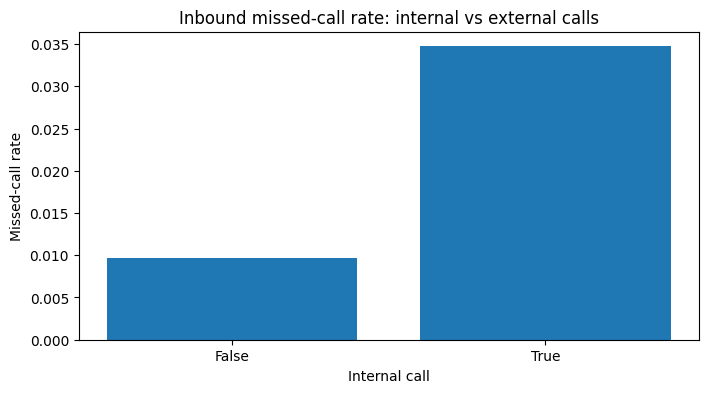

In [35]:
taxas_internal = contingencia_internal.copy()
taxas_internal['total'] = taxas_internal['not_missed'] + taxas_internal['missed']
taxas_internal['missed_rate'] = taxas_internal['missed'] / taxas_internal['total']

display(taxas_internal)

plt.figure(figsize=(8, 4))
plt.bar(taxas_internal.index.astype(str), taxas_internal['missed_rate'])
plt.title('Inbound missed-call rate: internal vs external calls')
plt.xlabel('Internal call')
plt.ylabel('Missed-call rate')
plt.show()

In [36]:
display(Markdown(f"""
**Hypothesis 2 conclusion:** {interpretar_pvalor(p_chi, alpha)}. The p-value was **{p_chi:.6f}**.

There is a statistically significant difference between internal and external inbound calls. This finding can help guide operational actions by call type, but it should be interpreted alongside the very different volumes in each group.
"""))


**Hypothesis 2 conclusion:** Reject H0. The p-value was **0.000000**.

There is a statistically significant difference between internal and external inbound calls. This finding can help guide operational actions by call type, but it should be interpreted alongside the very different volumes in each group.


### Hypothesis 3 — Inbound Workload and Missed-Call Rate

**H0:** There is no association between inbound calls per active day and the inbound missed-call rate.

**H1:** There is an association between inbound calls per active day and the inbound missed-call rate.

I use **Spearman correlation** because inbound call volume is skewed.


In [37]:
base_teste_carga = operator_classification[
    operator_classification['eligible_inbound']
].dropna(subset=['inbound_calls_per_active_day', 'missed_rate'])

spearman_load = stats.spearmanr(
    base_teste_carga['inbound_calls_per_active_day'],
    base_teste_carga['missed_rate']
)

print('Spearman correlation:', round(spearman_load.statistic, 4))
print('p-value:', spearman_load.pvalue)
print('Decision:', interpretar_pvalor(spearman_load.pvalue, alpha))

Spearman correlation: 0.1496
p-value: 0.0048669421017119106
Decision: Reject H0


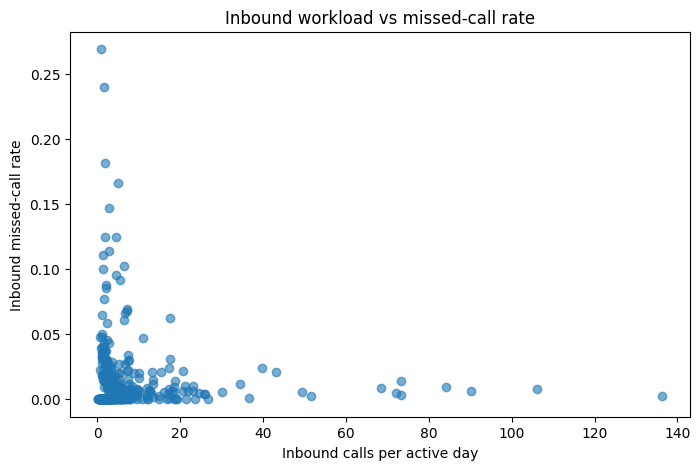

In [38]:
plt.figure(figsize=(8, 5))
plt.scatter(base_teste_carga['inbound_calls_per_active_day'], base_teste_carga['missed_rate'], alpha=0.6)
plt.title('Inbound workload vs missed-call rate')
plt.xlabel('Inbound calls per active day')
plt.ylabel('Inbound missed-call rate')
plt.show()

In [39]:
display(Markdown(f"""
**Hypothesis 3 conclusion:** {interpretar_pvalor(spearman_load.pvalue, alpha)}. The correlation was **{spearman_load.statistic:.4f}** and the p-value was **{spearman_load.pvalue:.4f}**.

There is a weak positive association between workload and missed-call rate. This suggests that workload may influence performance, but it should not be used alone to classify operators.
"""))


**Hypothesis 3 conclusion:** Reject H0. The correlation was **0.1496** and the p-value was **0.0049**.

There is a weak positive association between workload and missed-call rate. This suggests that workload may influence performance, but it should not be used alone to classify operators.


### Hypothesis 4 — Tariff Plan and Client Missed-Call Rate

**H0:** The distribution of inbound missed-call rates per client is the same across tariff plans A, B, and C.

**H1:** At least one tariff plan has a different distribution.

This is a complementary segmentation analysis. Tariff plan is not included in the operator score, but it may reveal differences between client groups.

I use the **Kruskal-Wallis test** because the metric is skewed.


In [40]:
base['operator_missing_calls_count'] = np.where(
    base['operator_id_int'].isna(),
    base['calls_count'],
    0
)

client_kpis = (
    base[base['direction'] == 'in']
    .groupby(['user_id', 'tariff_plan'])
    .agg(
        inbound_calls=('calls_count', 'sum'),
        missed_inbound_calls=('missed_calls_count', 'sum'),
        inbound_wait_total=('wait_duration', 'sum'),
        operator_missing_calls=('operator_missing_calls_count', 'sum')
    )
    .reset_index()
)

client_kpis['client_missed_rate'] = client_kpis['missed_inbound_calls'] / client_kpis['inbound_calls']
client_kpis['avg_wait_per_in_call'] = client_kpis['inbound_wait_total'] / client_kpis['inbound_calls']
client_kpis['operator_missing_rate'] = client_kpis['operator_missing_calls'] / client_kpis['inbound_calls']

client_kpis_eligible = client_kpis[client_kpis['inbound_calls'] >= 20].copy()
display(client_kpis_eligible.head())

,user_id,tariff_plan,inbound_calls,missed_inbound_calls,inbound_wait_total,operator_missing_calls,client_missed_rate,avg_wait_per_in_call,operator_missing_rate
0,166377,B,196,94,2093,94,0.4796,10.6786,0.4796
1,166391,C,26,20,662,20,0.7692,25.4615,0.7692
2,166392,C,209,107,3730,107,0.5120,17.8469,0.5120
3,166399,C,24,11,545,13,0.4583,22.7083,0.5417
4,166405,B,7711,5537,114522,5520,0.7181,14.8518,0.7159


In [41]:
resumo_planos = (
    client_kpis_eligible.groupby('tariff_plan')
    .agg(
        clients=('user_id', 'nunique'),
        inbound_calls=('inbound_calls', 'sum'),
        avg_missed_rate=('client_missed_rate', 'mean'),
        median_missed_rate=('client_missed_rate', 'median'),
        avg_missing_operator_rate=('operator_missing_rate', 'mean')
    )
    .reset_index()
)

display(resumo_planos)

grupos_plano = [
    grupo['client_missed_rate'].values
    for _, grupo in client_kpis_eligible.groupby('tariff_plan')
]

kruskal_plan = stats.kruskal(*grupos_plano)

print('Kruskal-Wallis statistic:', round(kruskal_plan.statistic, 4))
print('p-value:', kruskal_plan.pvalue)
print('Decision:', interpretar_pvalor(kruskal_plan.pvalue, alpha))

,tariff_plan,clients,inbound_calls,avg_missed_rate,median_missed_rate,avg_missing_operator_rate
0,A,31,90772,0.5134,0.4091,0.5085
1,B,87,52818,0.6130,0.6363,0.6079
2,C,124,53679,0.4735,0.4437,0.4687


Kruskal-Wallis statistic: 15.3293
p-value: 0.00046913062663822113
Decision: Reject H0


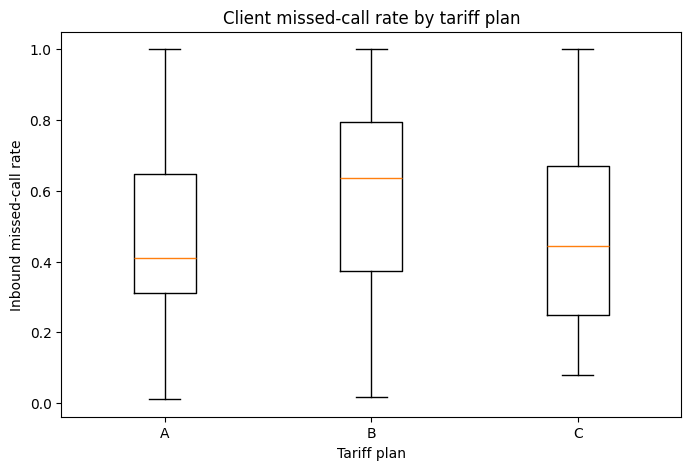

In [42]:
planos = sorted(client_kpis_eligible['tariff_plan'].dropna().unique())
dados_boxplot = [
    client_kpis_eligible.loc[client_kpis_eligible['tariff_plan'] == plano, 'client_missed_rate']
    for plano in planos
]

plt.figure(figsize=(8, 5))
plt.boxplot(dados_boxplot, tick_labels=planos)
plt.title('Client missed-call rate by tariff plan')
plt.xlabel('Tariff plan')
plt.ylabel('Inbound missed-call rate')
plt.show()

In [43]:
display(Markdown(f"""
**Hypothesis 4 conclusion:** {interpretar_pvalor(kruskal_plan.pvalue, alpha)}. The p-value was **{kruskal_plan.pvalue:.6f}**.

The distribution of client missed-call rates differs across tariff plans. This should be treated as a segmentation insight rather than as an individual operator-efficiency criterion.
"""))


**Hypothesis 4 conclusion:** Reject H0. The p-value was **0.000469**.

The distribution of client missed-call rates differs across tariff plans. This should be treated as a segmentation insight rather than as an individual operator-efficiency criterion.


## 12. Results Summary

I consolidate the most important metrics into a concise summary that can be communicated clearly to stakeholders.


In [44]:
metricas_finais = pd.Series({
    'original_records': len(telecom_raw),
    'records_after_cleaning': len(base),
    'duplicates_removed': len(telecom_raw) - len(base),
    'total_call_volume': int(base['calls_count'].sum()),
    'active_clients': base['user_id'].nunique(),
    'identified_operators': operator_classification['operator_id'].nunique(),
    'overall_missed_rate': base['missed_calls_count'].sum() / base['calls_count'].sum(),
    'inbound_missed_rate': recebidas['missed_calls_count'].sum() / recebidas['calls_count'].sum(),
    'share_inbound_without_operator': volume_recebidas_sem_operador / volume_recebidas,
    'missed_rate_inbound_without_operator': perdidas_recebidas_sem_operador / volume_recebidas_sem_operador,
    'missed_rate_inbound_with_operator': perdidas_recebidas_com_operador / volume_recebidas_com_operador,
    'high_priority_operators': (operator_classification['priority'] == 'high priority').sum(),
    'attention_operators': (operator_classification['priority'] == 'attention').sum()
})

display(metricas_finais.to_frame('value'))

,value
original_records,"53,902.0000"
records_after_cleaning,"49,002.0000"
duplicates_removed,"4,900.0000"
total_call_volume,"806,709.0000"
active_clients,307.0000
identified_operators,"1,092.0000"
overall_missed_rate,0.4660
inbound_missed_rate,0.5273
share_inbound_without_operator,0.5259
missed_rate_inbound_without_operator,0.9938


In [45]:
display(Markdown(f"""
### Executive Summary

The final dataset contains **{len(base):,} records** after removing **{len(telecom_raw) - len(base):,} exact duplicates**, representing **{int(base['calls_count'].sum()):,} calls**.

The most important finding is that **{volume_recebidas_sem_operador / volume_recebidas:.1%}** of inbound calls do not have an identified operator, and the missed-call rate in this group is **{perdidas_recebidas_sem_operador / volume_recebidas_sem_operador:.1%}**. This means that a large share of missed calls should not be attributed directly to individual operators.

Among operators with sufficient data, the baseline criteria flagged **{(operator_classification['priority'] == 'high priority').sum()} high-priority operators** and **{(operator_classification['priority'] == 'attention').sum()} operators requiring attention**.

The statistical tests identified significant but weak associations between waiting time/workload and missed-call rate. I therefore recommend using the score as a prioritisation and investigation tool rather than as an automatic performance judgement.
"""))


### Executive Summary

The final dataset contains **49,002 records** after removing **4,900 exact duplicates**, representing **806,709 calls**.

The most important finding is that **52.6%** of inbound calls do not have an identified operator, and the missed-call rate in this group is **99.4%**. This means that a large share of missed calls should not be attributed directly to individual operators.

Among operators with sufficient data, the baseline criteria flagged **152 high-priority operators** and **109 operators requiring attention**.

The statistical tests identified significant but weak associations between waiting time/workload and missed-call rate. I therefore recommend using the score as a prioritisation and investigation tool rather than as an automatic performance judgement.


## 13. Dashboard Data Export

I export analysis-ready datasets for Tableau Public or another business-intelligence tool.


In [46]:
daily_kpis = (
    base.groupby('date')
    .agg(
        total_calls=('calls_count', 'sum'),
        missed_calls=('missed_calls_count', 'sum'),
        wait_total=('wait_duration', 'sum')
    )
    .reset_index()
)

daily_in_out = (
    base.pivot_table(
        index='date',
        columns='direction',
        values='calls_count',
        aggfunc='sum',
        fill_value=0
    )
    .reset_index()
    .rename(columns={'in': 'inbound_calls', 'out': 'outbound_calls'})
)

daily_kpis = daily_kpis.merge(daily_in_out, on='date', how='left')
daily_kpis['missed_rate'] = daily_kpis['missed_calls'] / daily_kpis['total_calls']
daily_kpis['avg_wait_per_call'] = daily_kpis['wait_total'] / daily_kpis['total_calls']

operator_classification.to_csv('callmemaybe_operator_kpis.csv', index=False)
client_kpis.to_csv('callmemaybe_client_kpis.csv', index=False)
daily_kpis.to_csv('callmemaybe_daily_kpis.csv', index=False)
sensitivity_results.to_csv('callmemaybe_sensitivity_results.csv', index=False)

print('Exported files:')
print('- callmemaybe_operator_kpis.csv')
print('- callmemaybe_client_kpis.csv')
print('- callmemaybe_daily_kpis.csv')
print('- callmemaybe_sensitivity_results.csv')

Exported files:
- callmemaybe_operator_kpis.csv
- callmemaybe_client_kpis.csv
- callmemaybe_daily_kpis.csv
- callmemaybe_sensitivity_results.csv


## 14. Final Dashboard

The final dashboard was developed in **Tableau Public** to communicate the main findings clearly to supervisors and managers.

### Dashboard structure

- **Overview KPIs:** total operators, high-priority operators, operators requiring attention, and operators with no identified inefficiency signal.
- **Priority distribution:** number of operators in each classification level.
- **Waiting time vs missed calls:** relationship between average waiting time and missed-call rate, with priority visually identified.
- **Classification robustness:** frequency with which operators remain flagged during the sensitivity analysis.
- **Operator detail:** profile, operational indicators, score, and priority classification.

### Interactivity

The dashboard includes filters for:

- `Priority`
- `Profile`

The filters affect the analytical visualisations and the operator-detail table, while the four top-level KPIs remain fixed to preserve the overall result context.

**Published dashboard:** [CallMeMaybe — Operator Efficiency](https://public.tableau.com/views/CallMeMaybe-EficinciadosOperadores/CallMeMaybe-Dashboard?:language=pt-BR&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)


## 15. Final Conclusion

CallMeMaybe can build a useful monitoring feature to identify operators showing potential signs of low efficiency, but the solution must account for operational context and data quality.

The most important finding is that a large share of missed inbound calls does not contain an `operator_id`. These calls should therefore be monitored separately as a possible routing, service, or data-recording issue rather than being treated as an individual operator failure.

For identified operators, I recommend using a transparent score based on three dimensions: inbound missed-call rate, average waiting time, and low outbound activity when applicable. The result should be used to **prioritise investigation by supervisors**, not as an automatic performance judgement.

### Practical recommendations

1. Implement a monitoring view for high-priority operators and operators requiring attention.
2. Separate operator-level alerts from alerts related to calls without an identified operator.
3. Review routing and call-assignment processes because missed calls are strongly concentrated in records without an operator.
4. Use statistical tests as decision support while keeping operational validation with supervisors.
5. Recalibrate thresholds when the company establishes official service and productivity targets.

### What I Learned

What I found most valuable in this project was learning how important it is to separate **data-quality problems from individual performance problems**. A simple KPI can easily lead to the wrong conclusion when the underlying data does not support attribution.

This project strengthened my ability to combine analytical work with business judgement: building transparent metrics, testing how stable the results are, and communicating findings in a way that supports investigation rather than automatic decisions.
